In [8]:
#Lab 4.2 —  RNN Basics: Forward/Backward Through Time
#1. RNN cell from scratch
import torch
import torch.nn as nn

class SimpleRNNCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()

        self.Wx = nn.Linear(input_size, hidden_size)
        self.Wh = nn.Linear(hidden_size, hidden_size)
        self.bias = nn.Parameter(torch.zeros(hidden_size))

    def forward(self, x, h):
        return torch.tanh(
            self.Wx(x) + self.Wh(h) + self.bias
        )


# Parameters
T = 5
input_size = 1
hidden_size = 10

# Create RNN cell
cell = SimpleRNNCell(input_size, hidden_size)

# Initial hidden state
h = torch.zeros(hidden_size)

# Random input sequence
x_seq = torch.randn(T, input_size)

# Process sequence one time step at a time
for t in range(T):
    h = cell(x_seq[t], h)
    print(f"Time step {t + 1}: {h.shape}")

print("Final hidden state:", h)

Time step 1: torch.Size([10])
Time step 2: torch.Size([10])
Time step 3: torch.Size([10])
Time step 4: torch.Size([10])
Time step 5: torch.Size([10])
Final hidden state: tensor([-0.4748,  0.7569,  0.0213, -0.4045, -0.8889,  0.0413, -0.9012,  0.8304,
         0.0423,  0.6398], grad_fn=<TanhBackward0>)


X shape: torch.Size([980, 20, 1])
Y shape: torch.Size([980])
Epoch 10, Loss: 0.075345
Epoch 20, Loss: 0.011357
Epoch 30, Loss: 0.002715
Epoch 40, Loss: 0.002073
Epoch 50, Loss: 0.000236


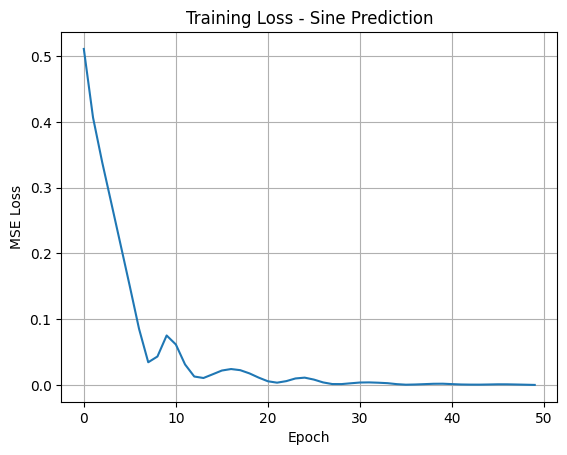

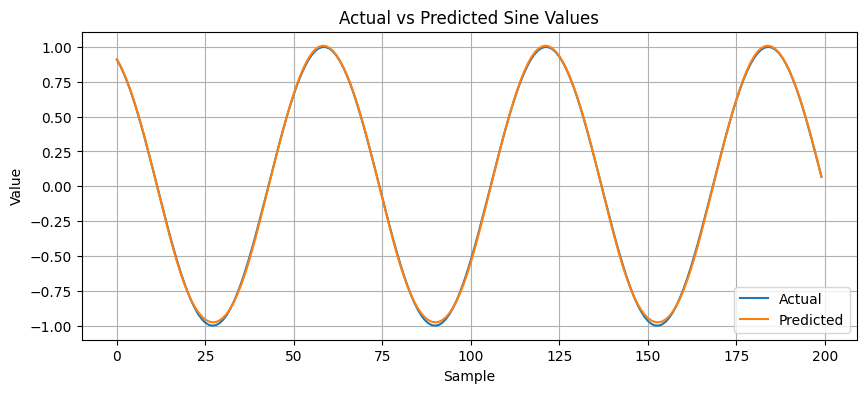

In [9]:
#2. Train small RNN for sine prediction

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# 1. Generate sine-wave dataset
torch.manual_seed(42)

t = torch.linspace(0, 100, 1000)
data = torch.sin(t)

# Create input sequences and next-value targets
seq_length = 20

X = torch.stack([
    data[i:i + seq_length]
    for i in range(len(data) - seq_length)
])

Y = torch.stack([
    data[i + seq_length]
    for i in range(len(data) - seq_length)
])

# Add input feature dimension
X = X.unsqueeze(-1)

print("X shape:", X.shape)
print("Y shape:", Y.shape)


# 2. Define RNN model
class RNNPredictor(nn.Module):
    def __init__(self, hidden=20):
        super().__init__()

        self.rnn = nn.RNN(
            input_size=1,
            hidden_size=hidden,
            batch_first=True
        )

        self.fc = nn.Linear(hidden, 1)

    def forward(self, x):
        h, _ = self.rnn(x)
        return self.fc(h[:, -1, :])


# 3. Create model and optimizer
model = RNNPredictor()

criterion = nn.MSELoss()

opt = torch.optim.Adam(
    model.parameters(),
    lr=0.01
)


# 4. Train model
losses = []

for ep in range(50):
    model.train()

    out = model(X)

    loss = criterion(
        out.squeeze(-1),
        Y
    )

    opt.zero_grad()
    loss.backward()
    opt.step()

    losses.append(loss.item())

    if (ep + 1) % 10 == 0:
        print(
            f"Epoch {ep + 1}, "
            f"Loss: {loss.item():.6f}"
        )


# 5. Plot training loss
plt.plot(losses)
plt.title("Training Loss - Sine Prediction")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()


# 6. Compare actual and predicted values
model.eval()

with torch.no_grad():
    predictions = model(X).squeeze(-1)

plt.figure(figsize=(10, 4))

plt.plot(
    Y[:200].numpy(),
    label="Actual"
)

plt.plot(
    predictions[:200].numpy(),
    label="Predicted"
)

plt.title("Actual vs Predicted Sine Values")
plt.xlabel("Sample")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()